In [1]:
%config Complter.use_jedi = False

In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

In [2]:
path = 'individual_companies/'

In [48]:
s_and_p = [
    'MMM','ABT','ABBV','ACN','ATVI','AYI','ADBE','AMD','AAP','AES','AET',
    'AMG','AFL','A','APD','AKAM','ALK','ALB','ARE','ALXN','ALGN','ALLE',
    'AGN','ADS','LNT','ALL','GOOGL','GOOG','MO','AMZN','AEE','AAL','AEP',
    'AXP','AIG','AMT','AWK','AMP','ABC','AME','AMGN','APH','APC','ADI','ANDV',
    'ANSS','ANTM','AON','AOS','APA','AIV','AAPL','AMAT','APTV','ADM','ARNC',
    'AJG','AIZ','T','ADSK','ADP','AZO','AVB','AVY','BHGE','BLL','BAC','BK',
    'BAX','BBT','BDX','BRK.B','BBY','BIIB','BLK','HRB','BA','BWA','BXP','BSX',
    'BHF','BMY','AVGO','BF.B','CHRW','CA','COG','CDNS','CPB','COF','CAH','CBOE',
    'KMX','CCL','CAT','CBG','CBS','CELG','CNC','CNP','CTL','CERN','CF','SCHW',
    'CHTR','CHK','CVX','CMG','CB','CHD','CI','XEC','CINF','CTAS','CSCO','C','CFG',
    'CTXS','CLX','CME','CMS','KO','CTSH','CL','CMCSA','CMA','CAG','CXO','COP',
    'ED','STZ','COO','GLW','COST','COTY','CCI','CSRA','CSX','CMI','CVS','DHI',
    'DHR','DRI','DVA','DE','DAL','XRAY','DVN','DLR','DFS','DISCA','DISCK','DISH',
    'DG','DLTR','D','DOV','DWDP','DPS','DTE','DRE','DUK','DXC','ETFC','EMN','ETN',
    'EBAY','ECL','EIX','EW','EA','EMR','ETR','EVHC','EOG','EQT','EFX','EQIX','EQR',
    'ESS','EL','ES','RE','EXC','EXPE','EXPD','ESRX','EXR','XOM','FFIV','FB','FAST',
    'FRT','FDX','FIS','FITB','FE','FISV','FLIR','FLS','FLR','FMC','FL','F','FTV',
    'FBHS','BEN','FCX','GPS','GRMN','IT','GD','GE','GGP','GIS','GM','GPC','GILD',
    'GPN','GS','GT','GWW','HAL','HBI','HOG','HRS','HIG','HAS','HCA','HCP','HP','HSIC',
    'HSY','HES','HPE','HLT','HOLX','HD','HON','HRL','HST','HPQ','HUM','HBAN','HII',
    'IDXX','INFO','ITW','ILMN','IR','INTC','ICE','IBM','INCY','IP','IPG','IFF','INTU',
    'ISRG','IVZ','IQV','IRM','JEC','JBHT','SJM','JNJ','JCI','JPM','JNPR','KSU','K','KEY',
    'KMB','KIM','KMI','KLAC','KSS','KHC','KR','LB','LLL','LH','LRCX','LEG','LEN','LUK',
    'LLY','LNC','LKQ','LMT','L','LOW','LYB','MTB','MAC','M','MRO','MPC','MAR','MMC','MLM',
    'MAS','MA','MAT','MKC','MCD','MCK','MDT','MRK','MET','MTD','MGM','KORS','MCHP','MU',
    'MSFT','MAA','MHK','TAP','MDLZ','MON','MNST','MCO','MS','MOS','MSI','MYL','NDAQ',
    'NOV','NAVI','NTAP','NFLX','NWL','NFX','NEM','NWSA','NWS','NEE','NLSN','NKE','NI',
    'NBL','JWN','NSC','NTRS','NOC','NCLH','NRG','NUE','NVDA','ORLY','OXY','OMC','OKE',
    'ORCL','PCAR','PKG','PH','PDCO','PAYX','PYPL','PNR','PBCT','PEP','PKI','PRGO','PFE',
    'PCG','PM','PSX','PNW','PXD','PNC','RL','PPG','PPL','PX','PCLN','PFG','PG','PGR',
    'PLD','PRU','PEG','PSA','PHM','PVH','QRVO','PWR','QCOM','DGX','RRC','RJF','RTN','O',
    'RHT','REG','REGN','RF','RSG','RMD','RHI','ROK','COL','ROP','ROST','RCL','CRM','SBAC',
    'SCG','SLB','SNI','STX','SEE','SRE','SHW','SIG','SPG','SWKS','SLG','SNA','SO','LUV',
    'SPGI','SWK','SBUX','STT','SRCL','SYK','STI','SYMC','SYF','SNPS','SYY','TROW','TPR',
    'TGT','TEL','FTI','TXN','TXT','TMO','TIF','TWX','TJX','TMK','TSS','TSCO','TDG','TRV',
    'TRIP','FOXA','FOX','TSN','UDR','ULTA','USB','UAA','UA','UNP','UAL','UNH','UPS','URI',
    'UTX','UHS','UNM','VFC','VLO','VAR','VTR','VRSN','VRSK','VZ','VRTX','VIAB','V','VNO',
    'VMC','WMT','WBA','DIS','WM','WAT','WEC','WFC','HCN','WDC','WU','WRK','WY','WHR','WMB',
    'WLTW','WYN','WYNN','XEL','XRX','XLNX','XL','XYL','YUM','ZBH','ZION','ZTS']

company_without_records = ['ALXN','AGN','APC','BHGE','BBT','BRK.B','BF.B','CBG','CBS','CELG','CTL',
                           'CXO','DWDP','DPS','ETFC','FLIR','GGP','HRS','HCP','JEC','LB','LUK','KORS',
                           'MYL','NBL','PCLN','RTN','RHT','STI','SYMC','TIF','TMK','TSS','UTX','VAR',
                           'VIAB','HCN','WYN']

incomplete_companies = ['AET', 'ANDV', 'ARNC', 'CA', 'CHK', 'XEC', 'CSRA', 'EVHC', 'ESRX', 'MON', 'NFX',
                        'PX', 'COL', 'SCG', 'SNI', 'TWX', 'FOXA', 'FOX', 'XL']

selected_companies = []
for comp in s_and_p:
    if comp not in company_without_records and comp not in incomplete_companies:
        selected_companies.append(comp)
len(selected_companies)

448

In [34]:
companyA = pd.read_csv(path+'AAPL.csv')
type(companyA.Close)

pandas.core.series.Series

In [37]:
l = []
l.append([companyA.Close])
l.append([companyB.Close])
l

[[0       37.097084
  1       37.550827
  2       39.063328
  3       39.454662
  4       40.182102
            ...    
  952    157.869995
  953    160.550003
  954    161.020004
  955    161.410004
  956    161.940002
  Name: Close, Length: 957, dtype: float64],
 [0       80.805305
  1       83.818497
  2       84.721542
  3       85.386902
  4       86.723915
            ...    
  952    341.269989
  953    343.109985
  954    339.829987
  955    337.679993
  956    337.910004
  Name: Close, Length: 957, dtype: float64]]

In [19]:
companyB = pd.read_csv(path+'MSFT.csv')
companyB.Close

0       80.805305
1       83.818497
2       84.721542
3       85.386902
4       86.723915
          ...    
952    341.269989
953    343.109985
954    339.829987
955    337.679993
956    337.910004
Name: Close, Length: 957, dtype: float64

In [25]:
companyA_ratio = []
companyB_ratio = []
companyC_ratio = []
for i in range(1, len(companyA.Close)):
    companyA_ratio.append((companyA.Close[i]-companyA.Close[i-1])/companyA.Close[i-1])
    companyB_ratio.append((companyB.Close[i]-companyB.Close[i-1])/companyB.Close[i-1])
    companyC_ratio.append((companyC.Close[i]-companyC.Close[i-1])/companyC.Close[i-1])

In [93]:
np.corrcoef(companyA.Close, companyC.Close)

array([[1.        , 0.94677292],
       [0.94677292, 1.        ]])

In [33]:
np.corrcoef(companyA_ratio,companyB_ratio)

array([[1.        , 0.75749021],
       [0.75749021, 1.        ]])

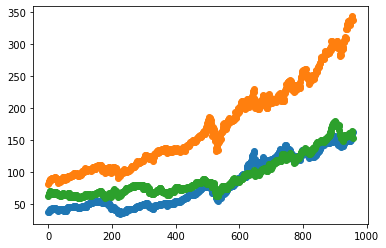

In [15]:
plt.scatter(companyA.index,companyA.Close)
plt.scatter(companyB.index,companyB.Close)
plt.scatter(companyC.index,companyC.Close)

In [29]:
len(companyA_ratio)

956

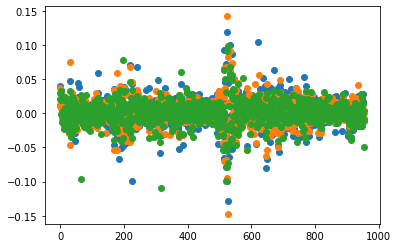

In [31]:
plt.scatter(range(956),companyA_ratio)
plt.scatter(range(956),companyB_ratio)
plt.scatter(range(956),companyC_ratio)

In [38]:
companyC = pd.read_csv(path+'A.csv')


## save company and close price in a dictionary, and build a graph though Pearson's rank

In [49]:
comp_closeprice_dict = {}
for company in selected_companies:
    df = pd.read_csv(path+company+'.csv')
    comp_closeprice_dict[company] = df.Close

In [59]:
for i in comp_closeprice_dict:
#     plt.scatter(range(957),comp_closeprice_dict[i])
    if len(comp_closeprice_dict[i]) != 957 :
        comp_closeprice_dict[i].pop(957)
        print(i, len(comp_closeprice_dict[i]))


ETR 957
RMD 957
SBUX 957


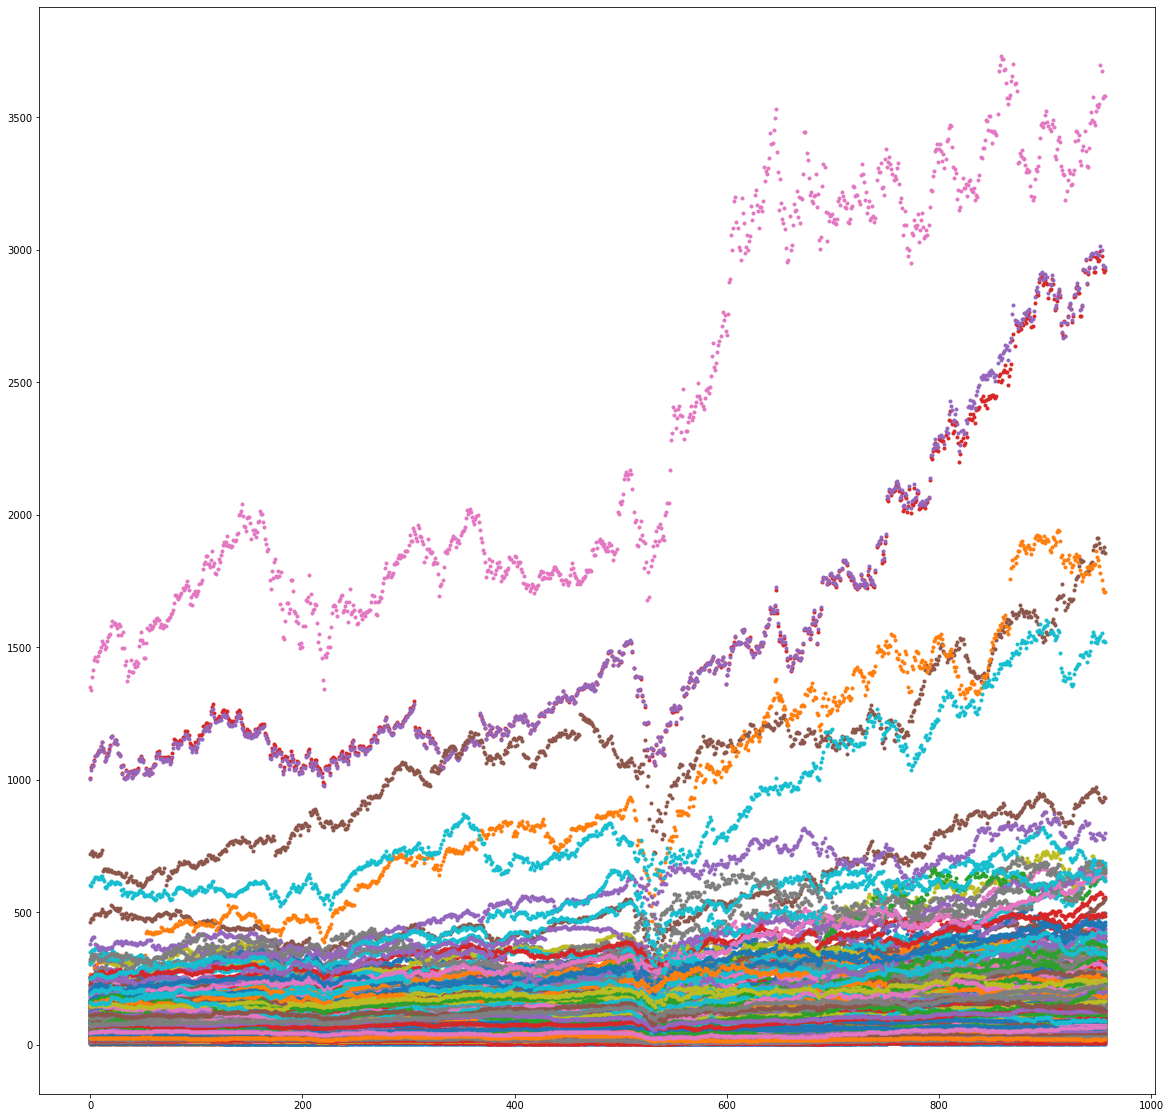

In [66]:
plt.figure(figsize=(20,20))
for i in comp_closeprice_dict:
    plt.scatter(range(957),comp_closeprice_dict[i],marker='.')


In [73]:
scaler = MinMaxScaler()

In [91]:
scaler.fit_transform(np.array(comp_closeprice_dict['MMM']).reshape(-1,1)).reshape(1,-1)

array([[0.80992729, 0.82936244, 0.86270317, 0.88088145, 0.8862425 ,
        0.92188636, 0.93705447, 0.92357186, 0.89921968, 0.93140848,
        0.94000367, 1.        , 0.9716872 , 0.92727963, 0.89214148,
        0.88396767, 0.90452775, 0.91169072, 0.92778534, 0.93427364,
        0.97649043, 0.96342905, 0.94463838, 0.91699908, 0.93031273,
        0.94168889, 0.89399493, 0.90149465, 0.9157351 , 0.82329682,
        0.75748613, 0.7986076 , 0.76178351, 0.76742906, 0.79254038,
        0.7343975 , 0.76565965, 0.77602439, 0.78537756, 0.73127963,
        0.73599839, 0.77113697, 0.74880661, 0.76641793, 0.75883431,
        0.77720404, 0.79734303, 0.79254038, 0.78689469, 0.77762542,
        0.76186784, 0.63757737, 0.61828055, 0.60353425, 0.59536073,
        0.58078296, 0.58609161, 0.58170961, 0.59165268, 0.62266241,
        0.63024603, 0.6427175 , 0.6568739 , 0.6704407 , 0.67153587,
        0.67659195, 0.64836334, 0.62982523, 0.64263578, 0.63075812,
        0.65451344, 0.63084289, 0.62829736, 0.63

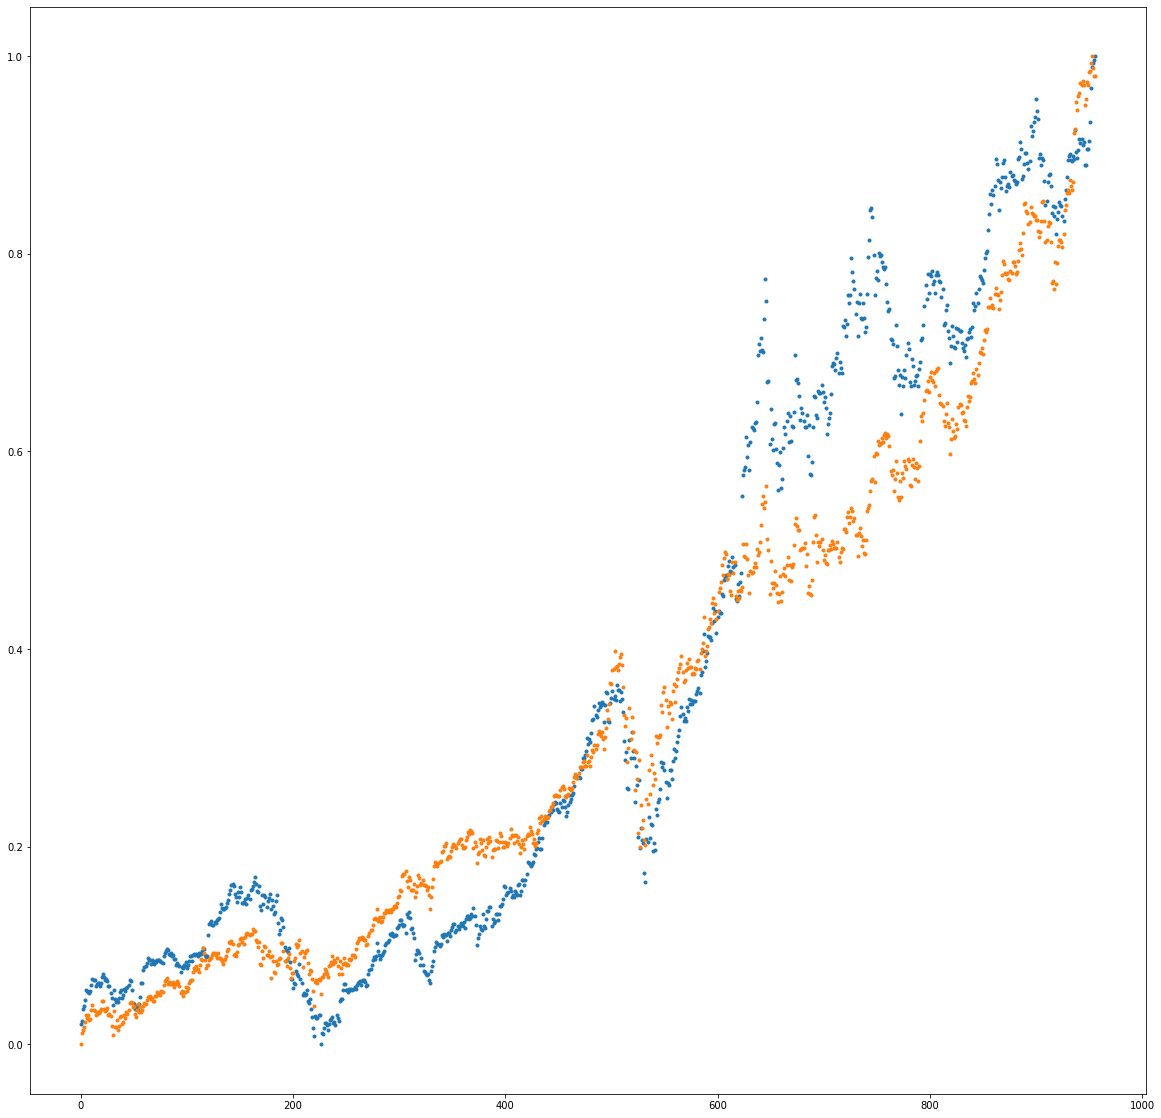

In [89]:
plt.figure(figsize=(20,20))
for i in ['AAPL','MSFT',]:
    plt.scatter(range(957),scaler.fit_transform(np.array(comp_closeprice_dict[i]).reshape(-1,1)),marker='.')


In [112]:
## compute correlation with the close price
corr = pd.DataFrame(index=selected_companies, columns=selected_companies)
for i in range(len(selected_companies)-1):
    for j in range(i, len(selected_companies)):
        company_i = selected_companies[i]
        company_j = selected_companies[j]
        corr_ij = np.corrcoef(comp_closeprice_dict[company_i], comp_closeprice_dict[company_j])[0,1]
        corr[company_j][company_i] = corr_ij

In [113]:
corr

,MMM,ABT,ABBV,ACN,ATVI,AYI,ADBE,AMD,AAP,AES,...,WLTW,WYNN,XEL,XRX,XLNX,XYL,YUM,ZBH,ZION,ZTS
MMM,1.0,0.041476,0.469608,0.209028,0.305075,0.673378,0.102047,0.031139,0.43382,0.241094,...,0.010548,0.543803,-0.277101,0.132869,0.18274,0.411541,0.190908,0.195313,0.720995,0.014843
ABT,NaN,1.0,0.730808,0.93788,0.618713,0.41499,0.948973,0.9531,0.681624,0.901651,...,0.916175,-0.473698,0.867637,-0.293506,0.839858,0.847952,0.790779,0.804505,0.261919,0.958955
ABBV,NaN,NaN,1.0,0.822083,0.808874,0.583275,0.807526,0.774424,0.594306,0.711976,...,0.660272,-0.053745,0.455037,-0.338179,0.586124,0.811821,0.522357,0.644112,0.560125,0.746899
ACN,NaN,NaN,NaN,1.0,0.613202,0.639093,0.964552,0.943183,0.783338,0.872937,...,0.88205,-0.328399,0.752081,-0.235303,0.855757,0.942685,0.84229,0.767947,0.487722,0.963868
ATVI,NaN,NaN,NaN,NaN,1.0,0.269512,0.662954,0.630393,0.314235,0.560246,...,0.531633,-0.043937,0.397672,-0.472376,0.297701,0.56776,0.267094,0.615606,0.27209,0.58824
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
XYL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1.0,0.85913,0.743486,0.639923,0.872237
YUM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.746562,0.507476,0.804346
ZBH,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.398041,0.766903
ZION,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.279796


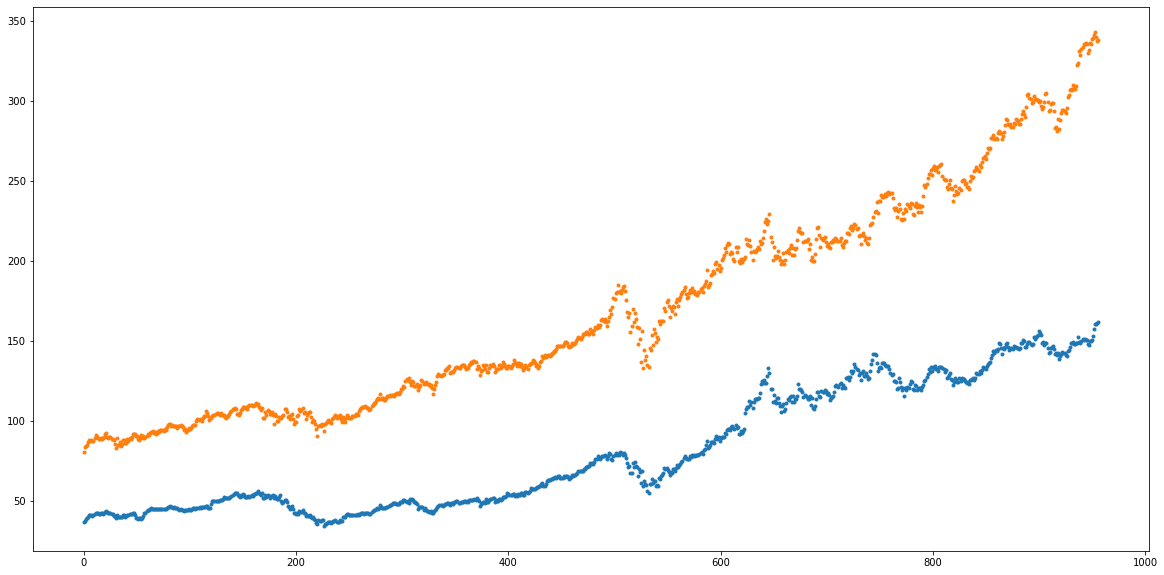

In [123]:
A = 'AAPL'
B = 'MSFT'
plt.figure(figsize=(20,10))
plt.scatter(range(957),comp_closeprice_dict[A], marker='.')
plt.scatter(range(957),comp_closeprice_dict[B], marker='.')

In [125]:
corr['MSFT']['AAPL']

0.9729870068714965

In [8]:
(70.11+69.89+68.44+69.54+68.61+69.63)/6

69.37

In [9]:
3.1/69.37

0.04468790543462592

In [10]:
((38.76-37.6)/3  7.6 + (66.86-66.58)/66.58 + (52.41-49.87)/49.87 + (51.64-44.22)/44.22 + (23.02-19.44)/19.44 + (7.73-7.45)/7.45 )/6

0.0792544338685147

In [11]:
((35.23-33.71)/33.71+(55.86-46.97)/46.97+(44.36-43.49)/43.49 + (33.79-31.78)/31.78 +(27.61-26.14)/26.14 + (9.54-8.69)/8.69)/6

0.07861023022769507